In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# Function that allows easy viewing of the data on a monthly basis
def monthly(df):
    df["DATE"] = pd.to_datetime(df["DATE"])
    return df.set_index("DATE").resample("MS").mean().reset_index()

# Function that makes it super easy to cut dates
def slice_dates(df, start, end):
    return df[(df["DATE"] >= start) & (df["DATE"] <= end)]

# Adds horizontal line
def horizontal_rule():
    plt.axhline(0, color="black", linestyle="--", linewidth=2)

# Function that simplifies smoothing out noise by changing the window size
def smooth(df, y, window_size):
    return df[y].rolling(window=window_size, center=True).mean()

<Axes: xlabel='DATE', ylabel='DGS10'>

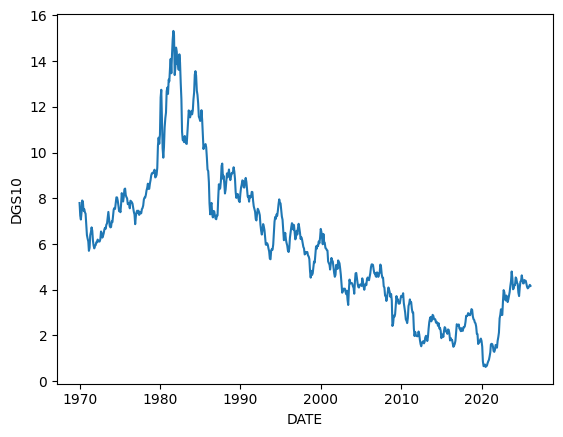

In [12]:
# 10 year bond yield interest rate 
ten_year_bond_yield = pd.read_csv("./datasets/GroupAssignment/economic_DGS10.csv")
# Cleaning the NaNs from the Dataset
ten_year_bond_yield = ten_year_bond_yield.dropna()
# Display Plot on a monthly basis
sns.lineplot(data=monthly(ten_year_bond_yield), x="DATE", y="DGS10")

<Axes: xlabel='DATE', ylabel='GDP'>

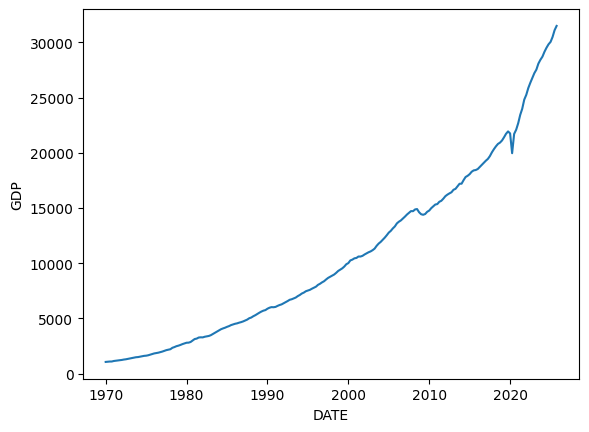

In [13]:
# 10 year bond yield interest rate 
GDP = pd.read_csv("./datasets/GroupAssignment/economic_GDP.csv")
# Cleaning the NaNs from the Dataset
GDP = GDP.dropna()
# Display Plot on a monthly basis
sns.lineplot(data=monthly(GDP), x="DATE", y="GDP")

<Axes: xlabel='DATE', ylabel='close'>

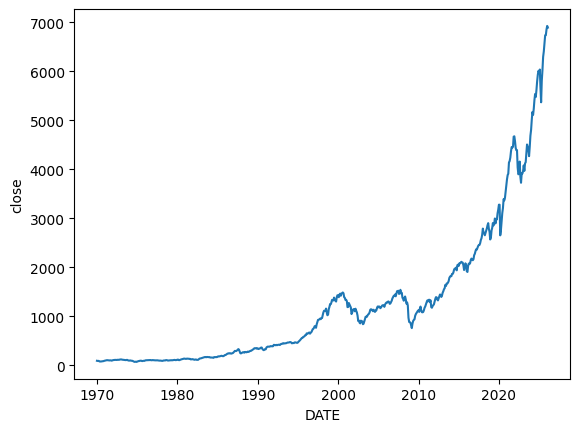

In [14]:
sp500 = pd.read_csv("./datasets/GroupAssignment/sp500_index.csv")
sp500.columns = [
    "date",
    "close",
    "high",
    "low",
    "open",
    "volume",
    "ticker"
]

# Removing non numerical, ticker values
sp500 = sp500.iloc[:, :6]
# Cleaning the NaNs from the Dataset
sp500 = sp500.dropna()
# Renaming date to DATE to make it compatible with the monthly() function
sp500 = sp500.rename(columns={"date": "DATE"})

# Display Plot on a monthly basis
sns.lineplot(data=monthly(sp500), x="DATE", y="close")


In [15]:
# Toolbox

# Percentage diffrence in change
ten_year_bond_yield["DGS10_change"] = ten_year_bond_yield["DGS10"].diff()

# Noise Reduction done to percentage difference in change
ten_year_bond_yield["DGS10_smoothed"] = smooth(ten_year_bond_yield, "DGS10_change", 80)

# DGS10 yield curve slope proxy
ten_year_bond_yield["DGS10_slope_proxy"] = (
    ten_year_bond_yield["DGS10"].diff(63)
)

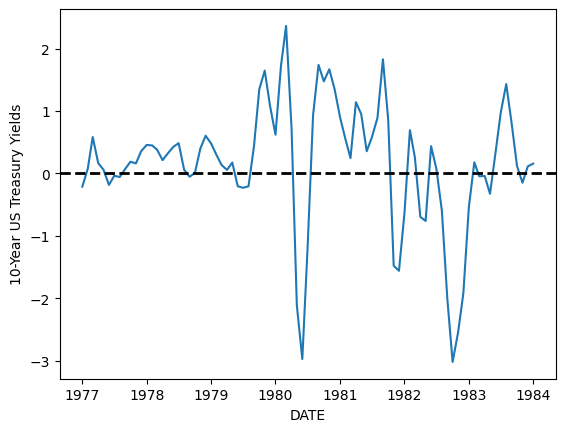

In [16]:
# Rename Y Axis
plt.ylabel("10-Year US Treasury Yields")

# Plot the 10 year treasury yields over time
sns.lineplot(data=slice_dates(monthly(ten_year_bond_yield), "1977-01-01", "1984-01-01").dropna(), x="DATE", y="DGS10_slope_proxy")

# add horizontal dotted line
horizontal_rule()

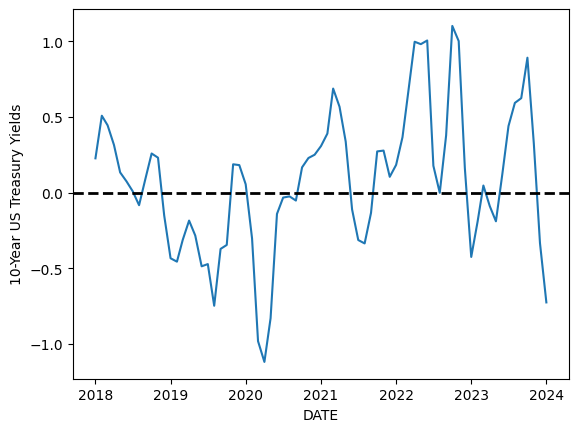

In [17]:
# Rename Y Axis
plt.ylabel("10-Year US Treasury Yields")

# Plot the 10 year treasury yields over time
sns.lineplot(data=slice_dates(monthly(ten_year_bond_yield), "2018-01-01", "2024-01-01").dropna(), x="DATE", y="DGS10_slope_proxy")

# add horizontal dotted line
horizontal_rule()

<Axes: xlabel='DATE', ylabel='GDP_smooth'>

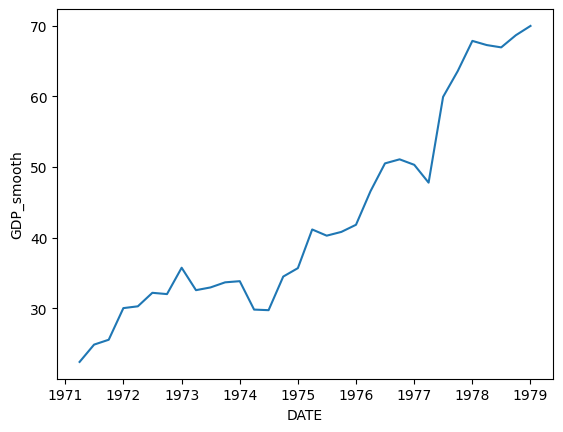

In [18]:
# Compute the period-to-period change in GDP
GDP['GDP_change'] = GDP['GDP'].diff()

# Apply a rolling mean to smooth out short-term fluctuations in GDP change
GDP['GDP_smooth'] = smooth(GDP, 'GDP_change', 8)

# Plot the smoothed GDP changes over time after slicing the data
sns.lineplot(data=slice_dates(monthly(GDP), "1971-01-01", "1979-01-01").dropna(), x="DATE", y="GDP_smooth")

<Axes: xlabel='DATE', ylabel='volume_smooth'>

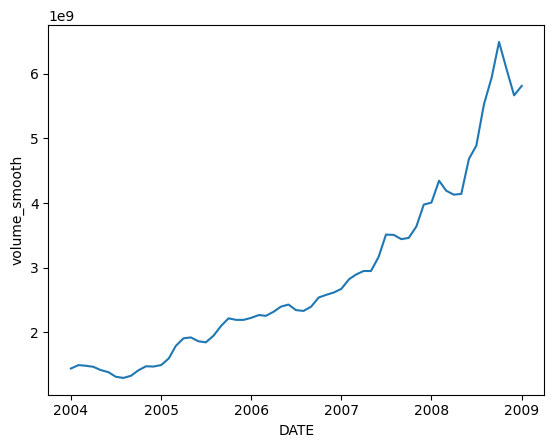

In [19]:
# Import S&P 500 for cleaning
sp500 = pd.read_csv("./datasets/GroupAssignment/sp500_index.csv")
sp500.columns = [
    "date",
    "close",
    "high",
    "low",
    "open",
    "volume",
    "ticker"
]

# Removing non numerical, ticker values
sp500 = sp500.iloc[:, :6]
# Cleaning the NaNs from the Dataset
sp500 = sp500.dropna()
# Renaming date to DATE to make it compatible with the monthly() function
sp500 = sp500.rename(columns={"date": "DATE"})

# Smoothing out data over a span of 3 months
sp500['volume_smooth'] = smooth(sp500, 'volume', 63)

# Display Plot on a monthly basis
sns.lineplot(data=slice_dates(monthly(sp500), "2004-01-01", "2009-01-01").dropna(), x="DATE", y="volume_smooth")
